# Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for clean visuals
plt.style.use('default')
sns.set_theme()

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import label_binarize

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,       # Overall accuracy
    confusion_matrix,     # Confusion matrix
    classification_report,# Precision, Recall, F1
    roc_auc_score,        # ROC-AUC score
    roc_curve             # ROC curve points
)

# Model Saving
import joblib

# Ignore warnings for clean output
import warnings
warnings.filterwarnings('ignore')

# Data Pre-processing and EDA

### Load Dataset

In [5]:
df = pd.read_csv("dataset.csv")
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


### Check info about the dataset

In [7]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64 

### Statistical Summary

In [9]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


### Target Variable Distribution

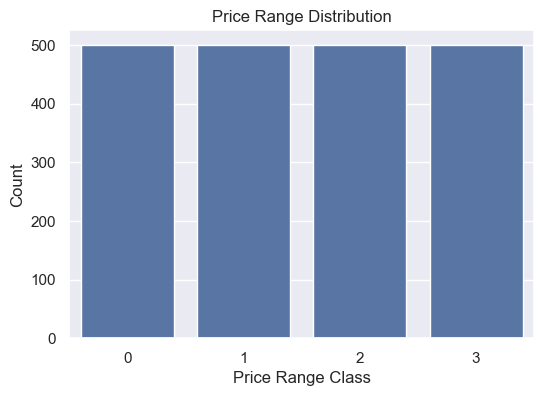

price_range
0    500
1    500
2    500
3    500
Name: count, dtype: int64


In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='price_range', data=df)
plt.title("Price Range Distribution")
plt.xlabel("Price Range Class")
plt.ylabel("Count")
plt.show()

# Numerical distribution
print(df['price_range'].value_counts().sort_index())

### Correlation Heatmap

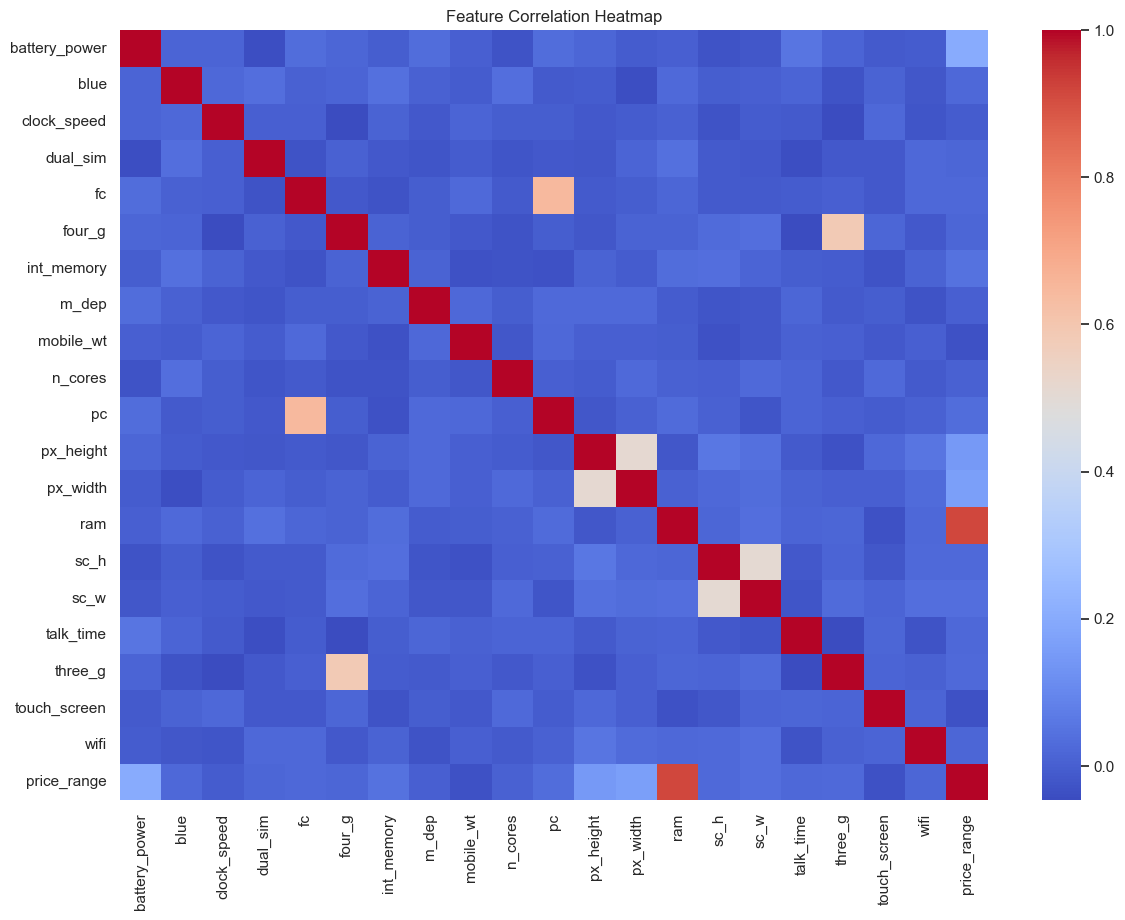

In [13]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

### Feature vs Target Correlation

In [15]:
target_corr = df.corr()['price_range'].sort_values(ascending=False)

print("Correlation with Price Range:\n")
print(target_corr)

Correlation with Price Range:

price_range      1.000000
ram              0.917046
battery_power    0.200723
px_width         0.165818
px_height        0.148858
int_memory       0.044435
sc_w             0.038711
pc               0.033599
three_g          0.023611
sc_h             0.022986
fc               0.021998
talk_time        0.021859
blue             0.020573
wifi             0.018785
dual_sim         0.017444
four_g           0.014772
n_cores          0.004399
m_dep            0.000853
clock_speed     -0.006606
mobile_wt       -0.030302
touch_screen    -0.030411
Name: price_range, dtype: float64


### Distribution Plots for Important Features

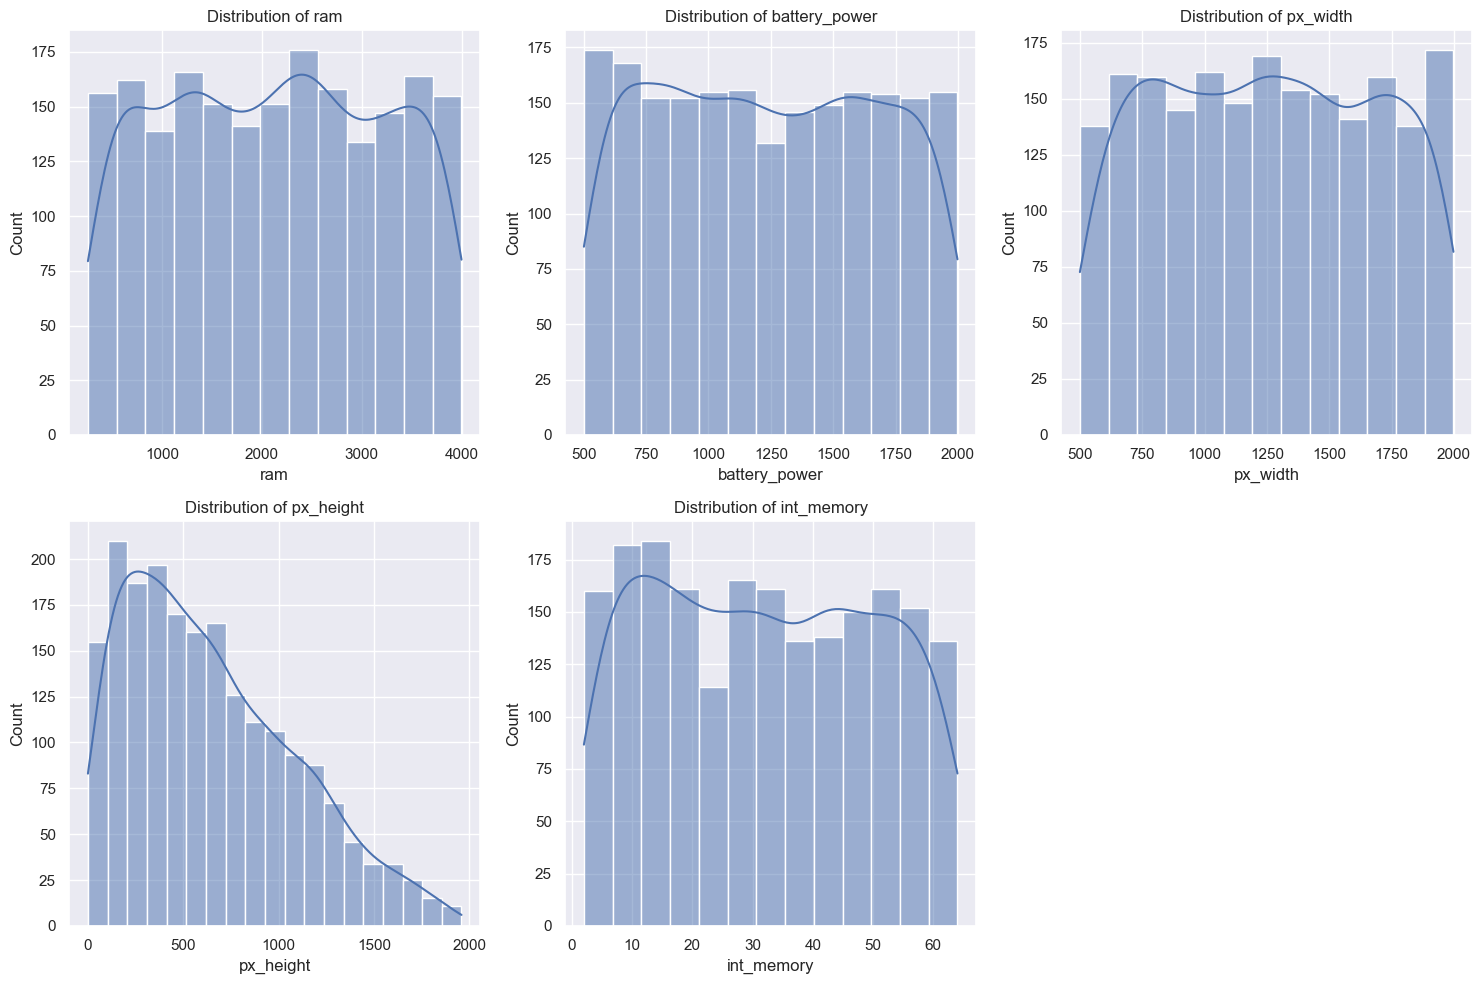

In [17]:
important_features = ['ram', 'battery_power', 'px_width', 'px_height', 'int_memory']

plt.figure(figsize=(15,10))

for i, col in enumerate(important_features, 1):
    plt.subplot(2,3,i)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

# Feature Engineering

### Split Features and Target

In [20]:
X = df.drop('price_range', axis=1)
y = df['price_range']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (2000, 20)
Target shape: (2000,)


### Train-Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # ⭐ important for multi-class balance
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1600, 20)
X_test shape: (400, 20)


### Feature Scaling

In [24]:
scaler = StandardScaler()

# Fit only on training data (to avoid leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Scaling completed.")

Scaling completed.


### Verify Scaling Results

In [26]:
X_train_scaled.describe().round(2)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
count,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00,1600.00
mean,-0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.68,-0.99,-1.26,-1.01,-1.00,-1.04,-1.65,-1.40,-1.70,-1.55,-1.63,-1.46,-1.74,-1.72,-1.73,-1.32,-1.63,-1.79,-1.01,-1.03
25%,-0.88,-0.99,-1.01,-1.01,-0.77,-1.04,-0.88,-1.05,-0.88,-0.68,-0.80,-0.82,-0.87,-0.84,-0.78,-0.86,-0.90,0.56,-1.01,-1.03
50%,-0.03,-0.99,-0.04,0.99,-0.30,0.96,-0.03,-0.01,0.03,0.20,0.02,-0.18,0.00,0.01,-0.07,-0.18,0.01,0.56,0.99,0.98
75%,0.86,1.01,0.85,0.99,0.62,0.96,0.87,1.03,0.85,1.07,0.84,0.69,0.86,0.86,0.89,0.73,0.93,0.56,0.99,0.98
max,1.74,1.01,1.80,0.99,3.38,0.96,1.75,1.72,1.70,1.51,1.67,2.96,1.75,1.73,1.60,2.79,1.65,0.56,0.99,0.98


# Model Training

### Initialize Models

In [29]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    multi_class='auto',
    random_state=42
)

### Train Random Forest

In [31]:
rf_model.fit(X_train_scaled, y_train)

print("Random Forest training completed.")

Random Forest training completed.


### Train Logistic Regression

In [33]:
lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


### Quick Training Accuracy Check

In [35]:
# Random Forest
rf_train_pred = rf_model.predict(X_train_scaled)
rf_train_acc = accuracy_score(y_train, rf_train_pred)

# Logistic Regression
lr_train_pred = lr_model.predict(X_train_scaled)
lr_train_acc = accuracy_score(y_train, lr_train_pred)

print("Logistic Regression Train Accuracy:", round(lr_train_acc, 4))
print("Random Forest Train Accuracy:", round(rf_train_acc, 4))

Logistic Regression Train Accuracy: 0.9769
Random Forest Train Accuracy: 1.0


# Model Evaluation

### Make Predictions on Test Set

In [38]:
# Random Forest predictions
rf_test_pred = rf_model.predict(X_test_scaled)

# Logistic Regression predictions
lr_test_pred = lr_model.predict(X_test_scaled)

print("Predictions completed.")

Predictions completed.


### Classification Report

In [40]:
print("🔹 Logistic Regression Report\n")
print(classification_report(y_test, lr_test_pred))

print("\n🔹 Random Forest Report\n")
print(classification_report(y_test, rf_test_pred))

🔹 Logistic Regression Report

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       100
           1       0.96      0.96      0.96       100
           2       0.95      0.94      0.94       100
           3       0.96      0.98      0.97       100

    accuracy                           0.96       400
   macro avg       0.97      0.96      0.96       400
weighted avg       0.97      0.96      0.96       400


🔹 Random Forest Report

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       100
           1       0.82      0.82      0.82       100
           2       0.82      0.81      0.81       100
           3       0.95      0.94      0.94       100

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.88      0.88      0.88       400



### Confusion Matrix

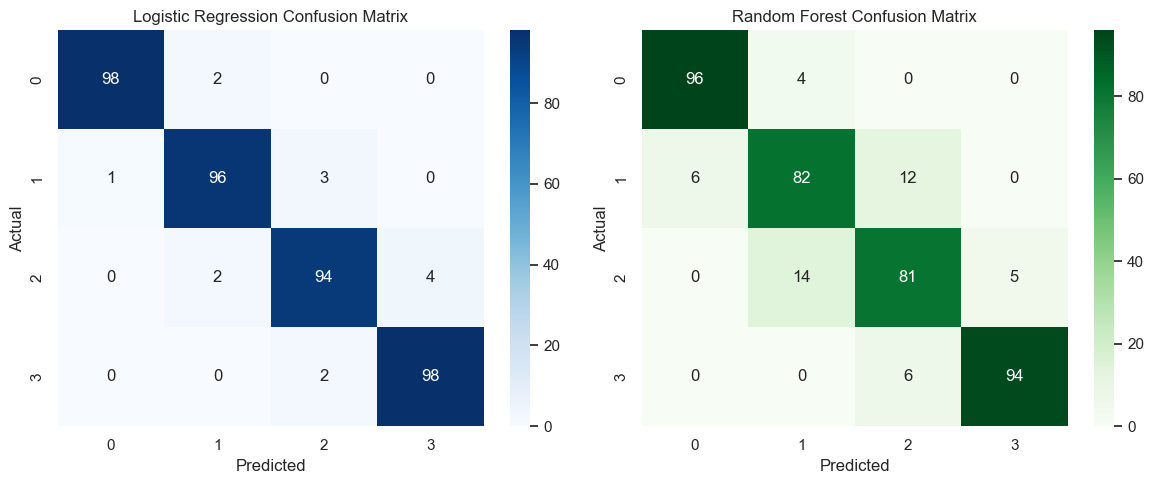

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Logistic Regression CM
sns.heatmap(
    confusion_matrix(y_test, lr_test_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title("Logistic Regression Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Random Forest CM
sns.heatmap(
    confusion_matrix(y_test, rf_test_pred),
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=axes[1]
)
axes[1].set_title("Random Forest Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

### ROC-AUC Scores

In [44]:
# Probability predictions
lr_proba = lr_model.predict_proba(X_test_scaled)
rf_proba = rf_model.predict_proba(X_test_scaled)

# ROC-AUC scores
lr_auc = roc_auc_score(y_test, lr_proba, multi_class='ovr')
rf_auc = roc_auc_score(y_test, rf_proba, multi_class='ovr')

print("Logistic Regression ROC-AUC:", round(lr_auc, 4))
print("Random Forest ROC-AUC:", round(rf_auc, 4))

Logistic Regression ROC-AUC: 0.9987
Random Forest ROC-AUC: 0.9804


### ROC Curve

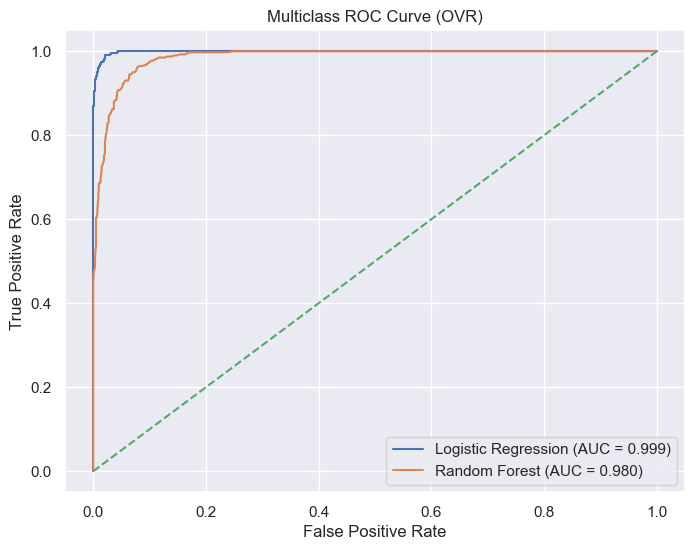

In [46]:
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8,6))

# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test_bin.ravel(), lr_proba.ravel())
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {lr_auc:.3f})')

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test_bin.ravel(), rf_proba.ravel())
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_auc:.3f})')

# Random guess line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve (OVR)")
plt.legend()
plt.grid(True)
plt.show()

### Final Model Selection

In [48]:
best_model = lr_model

print("Selected Model: Logistic Regression")
print("Reason: Highest test accuracy and best generalization.")

Selected Model: Logistic Regression
Reason: Highest test accuracy and best generalization.


### Actual vs Predicted Comparison Table

In [50]:
# Predict using best model
test_predictions = best_model.predict(X_test_scaled)

# Label mapping
price_labels = {
    0: "Low Cost",
    1: "Medium Cost",
    2: "High Cost",
    3: "Very High Cost"
}

# Build comparison table
comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": test_predictions
})

comparison_df["Actual Label"] = comparison_df["Actual"].map(price_labels)
comparison_df["Predicted Label"] = comparison_df["Predicted"].map(price_labels)

comparison_df["Correct Prediction"] = (
    comparison_df["Actual"] == comparison_df["Predicted"]
)

comparison_df.head(10)

,Actual,Predicted,Actual Label,Predicted Label,Correct Prediction
0,3,3,Very High Cost,Very High Cost,True
1,1,1,Medium Cost,Medium Cost,True
2,0,0,Low Cost,Low Cost,True
3,2,2,High Cost,High Cost,True
4,3,3,Very High Cost,Very High Cost,True
5,2,2,High Cost,High Cost,True
6,0,0,Low Cost,Low Cost,True
7,0,0,Low Cost,Low Cost,True
8,1,1,Medium Cost,Medium Cost,True
9,0,0,Low Cost,Low Cost,True


### Save Trained Model

In [79]:
joblib.dump(best_model, "mobile_price_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully.")

Model and scaler saved successfully.
